<a href="https://colab.research.google.com/github/FeLazarotto/SCTEC-Modulo2-MiniProjetoAvaliativo/blob/main/SCTEC_Modulo2_MiniProjetoAvaliativo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Imports, Funções e variavel para layout

from google.colab import drive
import shutil
import os
import zipfile
import tensorflow as tf
import pathlib
import matplotlib.pyplot as plt
import random
import cv2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

rep = 80

def criar_dataset_teste(path_ds, path_teste, quantidade=4):

    classes = os.listdir(path_ds)

    for classe in classes:

        caminho_classe = os.path.join(path_ds, classe)

        if not os.path.isdir(caminho_classe):
            continue

        caminho_teste_classe = os.path.join(path_teste, classe)
        os.makedirs(caminho_teste_classe, exist_ok=True)

        imagens = [
            arquivo for arquivo in os.listdir(caminho_classe)
            if arquivo.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        imagens_teste = random.sample(imagens, quantidade)

        for imagem in imagens_teste:

            origem = os.path.join(caminho_classe, imagem)
            destino = os.path.join(caminho_teste_classe, imagem)

            shutil.move(origem, destino)

            print(f"Movida: {classe}/{imagem}")


#Augmentation (Aplicando contrastes, iluminações variadas e espelhamento)
def augmentation_config(imagem, rotulo):
    imagem = tf.image.random_brightness(imagem, max_delta=0.2)
    imagem = tf.image.random_contrast(imagem, lower=0.8, upper=1.2)
    imagem = tf.image.random_flip_left_right(imagem)
    imagem = tf.image.random_flip_up_down(imagem)
    # imagem = tf.image.resize(imagem, (130, 130))
    return tf.clip_by_value(imagem, 0.0, 255.0), rotulo





################################################################################
-> 1. Baixando e Extraindo o Dataset.
################################################################################
O Dataset já foi extraida para o Colab!
 - Lendo dados da pasta: /content/dados/casting_512x512
 - Classes encontradas: ['ok_front', 'def_front']
As imagens já foram separadas anteriormente!

################################################################################
-> 2. Seleção de imagens para amostra e técnicas de manipulação de filtros.
################################################################################

Selecionando 4 imagens de amostra para cada classe


Exibindo imagens de amostra armazenadas:
 - Classe: ok_front (4 amostras)


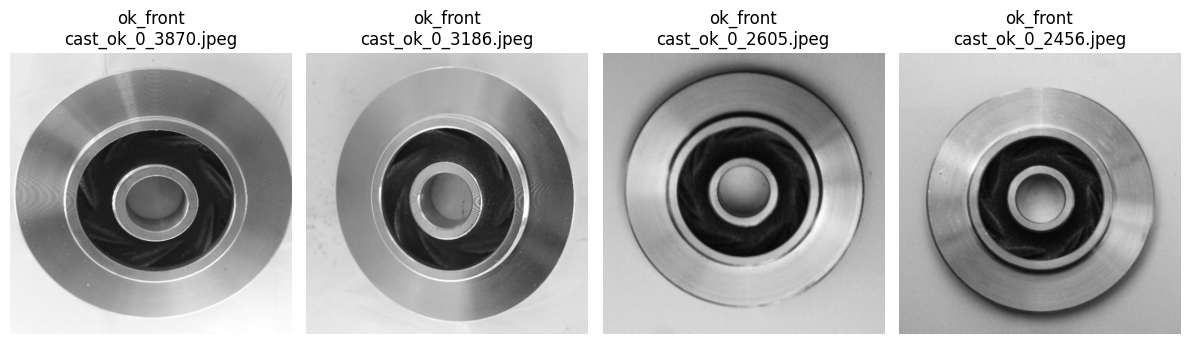

 - Classe: def_front (4 amostras)


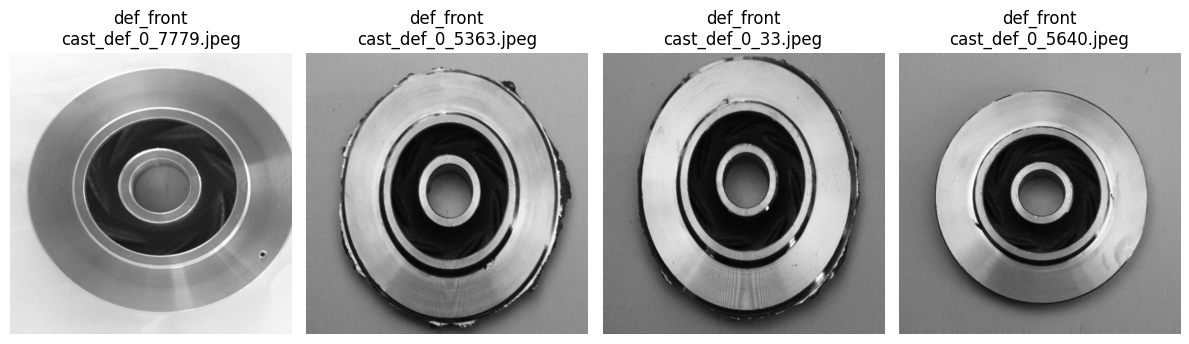


Exibindo amostras em Escala de Cinza:
 # Gray - Classe: ok_front (4 amostras)


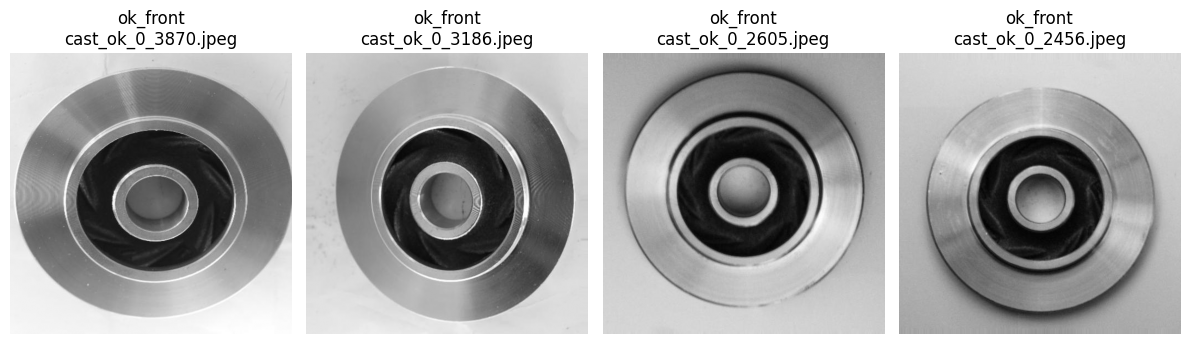

 # Gray - Classe: def_front (4 amostras)


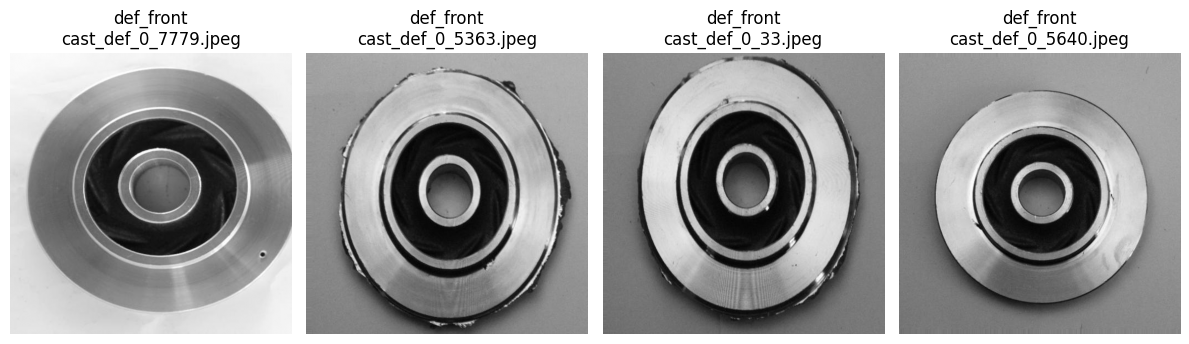


Exibindo amostras com Gaussian Blur:
 # Gaussian Blur - Classe: ok_front (4 amostras)


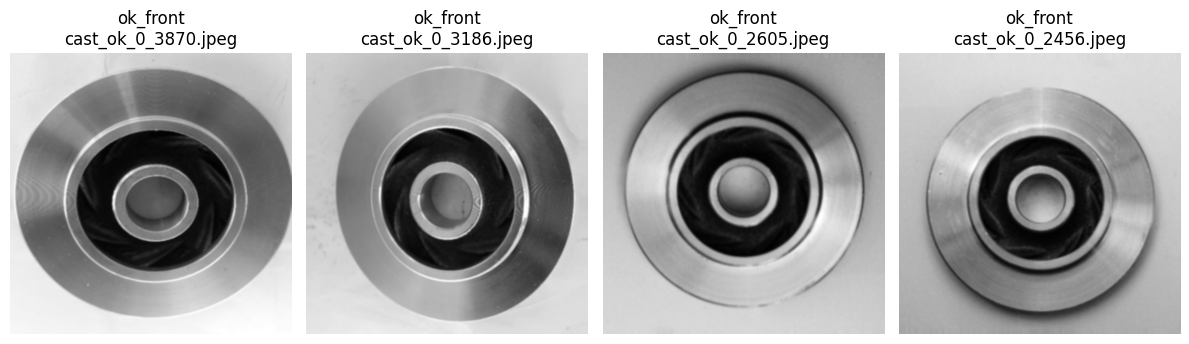

 # Gaussian Blur - Classe: def_front (4 amostras)


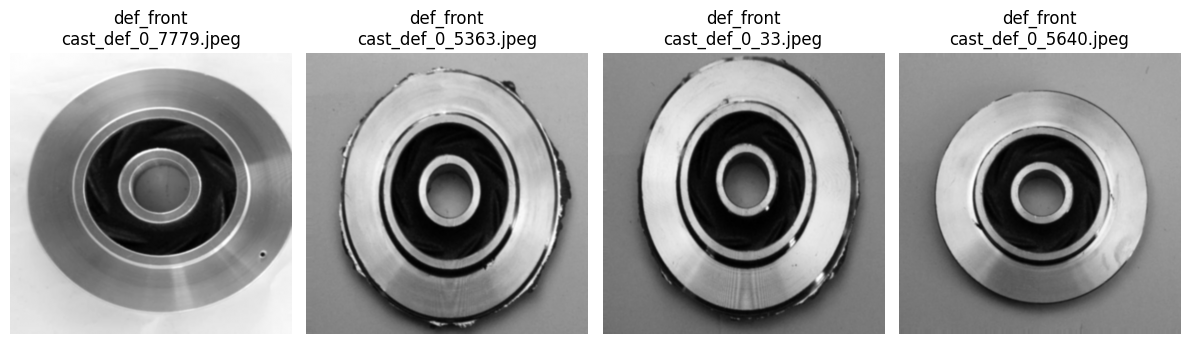


################################################################################
-> 3. Limiarização (Thresholding) e algoritmos de detecção de bordas.
################################################################################

Exibindo amostras com Binarização (Threshold):
 # Threshold - Classe: ok_front (4 amostras)


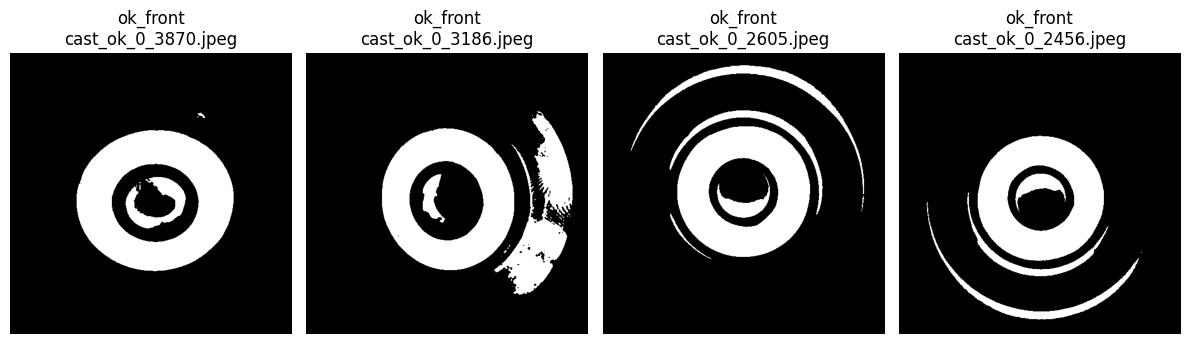

 # Threshold - Classe: def_front (4 amostras)


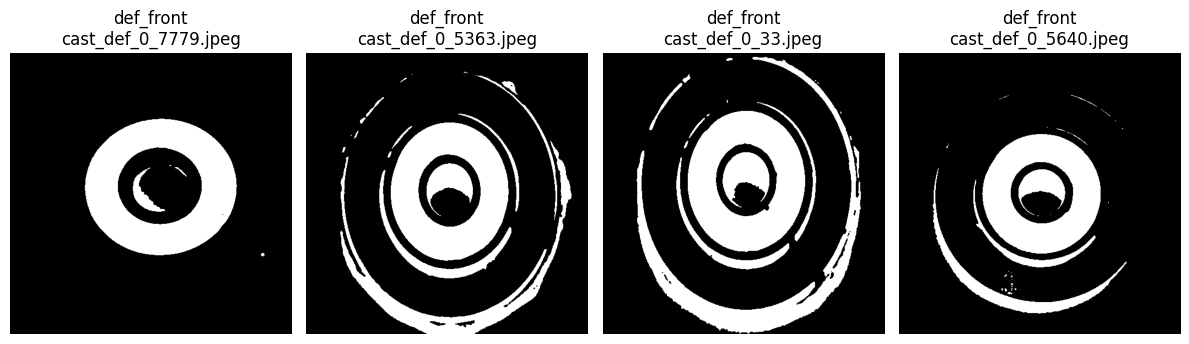


Exibindo amostras com Detecção de Bordas (Sobel):
 # Sobel - Classe: ok_front (4 amostras)


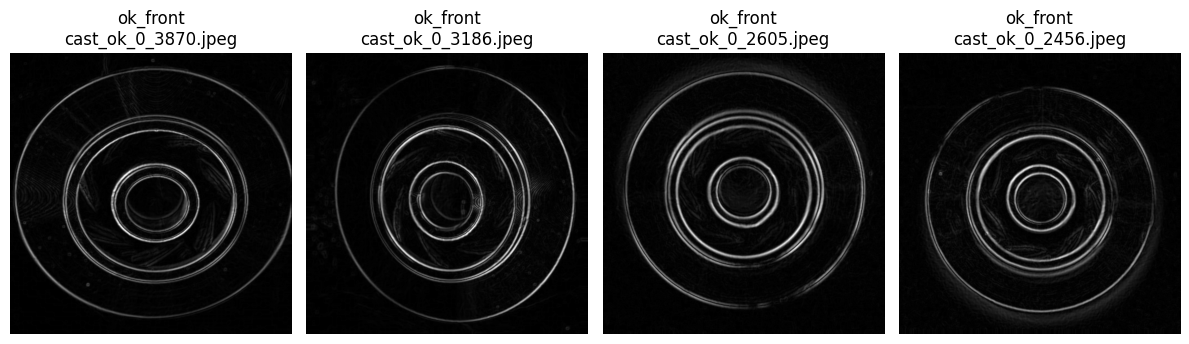

 # Sobel - Classe: def_front (4 amostras)


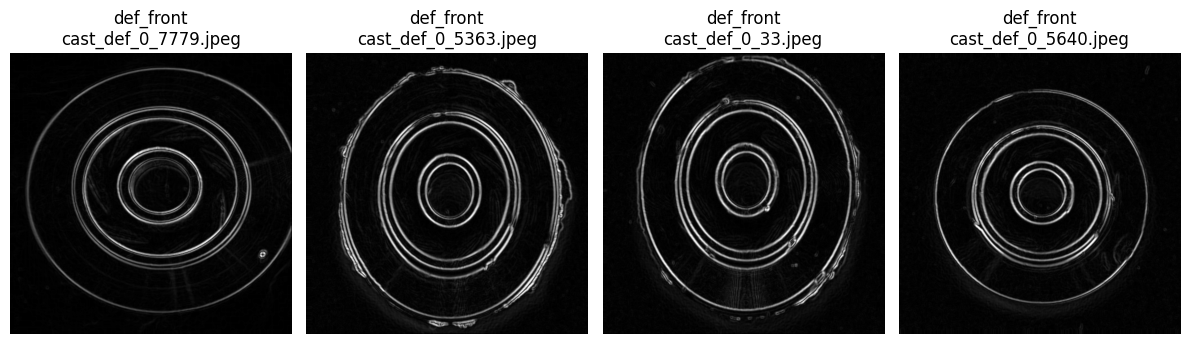


################################################################################
-> 4. Ingestão de Dados e Augmentation (Keras).
################################################################################

Utilizando image_dataset_from directory para carregar o dataset completo dividindo em Treino e Validação
Found 1292 files belonging to 2 classes.
Using 1034 files for training.
Found 1292 files belonging to 2 classes.
Using 258 files for validation.
Classes : ['def_front', 'ok_front']

################################################################################
-> 5. Arquitetura CNN e Treinamento.
################################################################################


Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 34s 473ms/step - accuracy: 0.6074 - loss: 0.7807 - val_accuracy: 0.3760 - val_loss: 2.1526
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 30s 460ms/step - accuracy: 0.5957 - loss: 0.6238 - val_accuracy: 0.3798 - val_loss: 2.8787
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 4

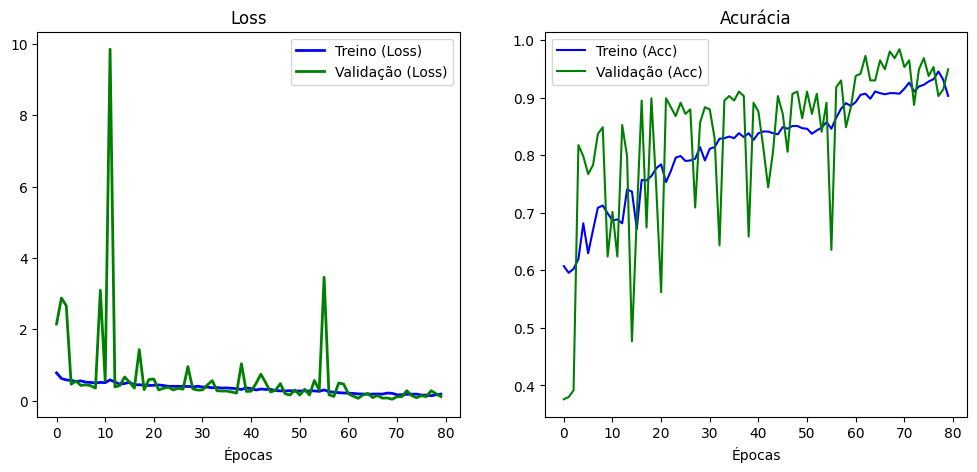


AUDITORIA: TESTANDO NO MUNDO REAL (DADOS DE VALIDAÇÃO)

[RELATÓRIO DE CLASSIFICAÇÃO]
              precision    recall  f1-score   support

   def_front       1.00      0.98      0.99       161
    ok_front       0.96      1.00      0.98        97

    accuracy                           0.98       258
   macro avg       0.98      0.99      0.98       258
weighted avg       0.99      0.98      0.98       258



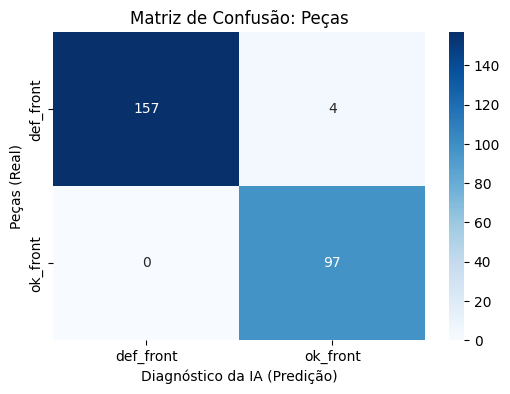


-> 4 peças do Teste Cego para a Prova Final:
Found 8 files belonging to 2 classes.


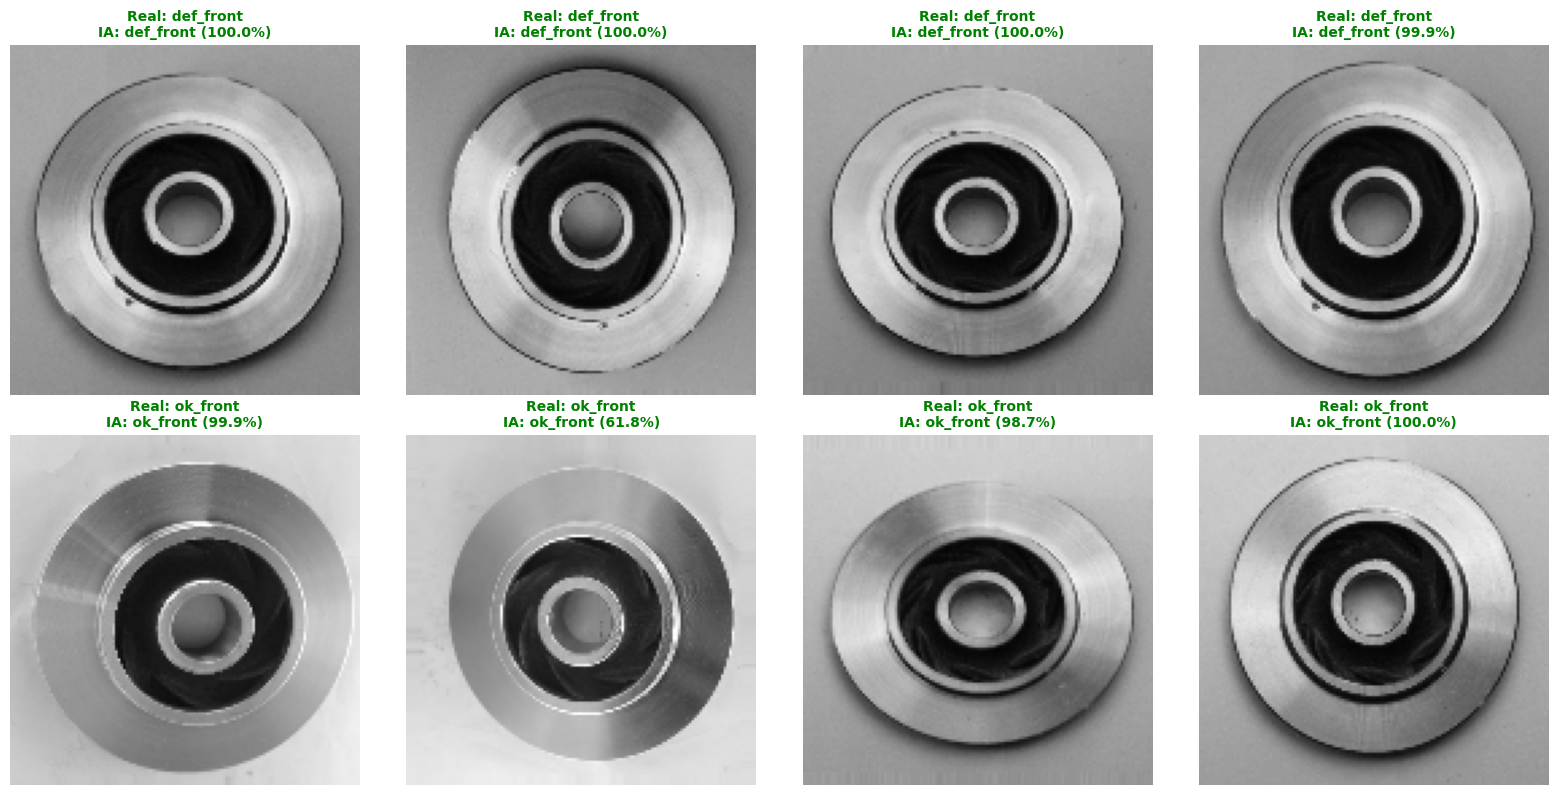

In [ ]:
# ==============================================================================
# 1. Inicialização e Configuração
# ==============================================================================
print ("\n"+"#"*rep)
print("-> 1. Baixando e Extraindo o Dataset.")
print ("#"*rep)
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/SCTEC-Modulo2-MiniProjetoAvaliativo/casting_512x512.zip"
pasta_raiz = os.path.splitext(os.path.basename(zip_path))[0]
pasta_extracao = pathlib.Path('/content/dados')
path_ds = pasta_extracao/pasta_raiz
path_teste = pathlib.Path('/content/dados/teste')

# Verificamos se já não extraímos antes para não perder tempo baixando de novo
if not os.path.exists(path_ds):
    print("   Extraindo as imagens para a pasta visível do Colab...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(pasta_extracao)
else:
    print("O Dataset já foi extraida para o Colab!")

subpastas = [f.name for f in path_ds.iterdir() if f.is_dir()]

print(f" - Lendo dados da pasta: {path_ds}")
print(f" - Classes encontradas: {subpastas}")

qnt_img_por_ds = 4
qnt_classes = len(subpastas)
# Verificamos se já movemos antes para não mover mais imagens
if not os.path.exists(path_teste):
    print("   Movendo imagens do teste final...")
    criar_dataset_teste(path_ds, path_teste, quantidade=qnt_img_por_ds)
else:
    print("As imagens já foram separadas anteriormente!")


# ==============================================================================
# 2. Análise Exploratória Clássica (OpenCV)
# ==============================================================================
print ("\n"+"#"*rep)
print("-> 2. Seleção de imagens para amostra e técnicas de manipulação de filtros.")
print ("#"*rep)

img_ext = ['**/*.jpeg', '**/*.jpg']
amostra_img_classe = {}

# Os prints explicam a selecao aleatoria de imagens do for
print("\nSelecionando 4 imagens de amostra para cada classe\n")

for class_name in subpastas:
    class_dir = path_ds / class_name
    all_image_paths = []
    for ext in img_ext:
        all_image_paths.extend(list(class_dir.glob(ext)))

    num_samples = min(4, len(all_image_paths))
    sample_image_paths = random.sample(all_image_paths, num_samples)


    amostra_img_classe[class_name] = []
    for img_path in sample_image_paths:
        img = cv2.imread(str(img_path))

        if img is not None:

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            amostra_img_classe[class_name].append((img_rgb, img_path.name))
        else:
            print(f"   Erro ao carregar a imagem: {img_path.name}")


print("\nExibindo imagens de amostra armazenadas:")
for class_name in subpastas:

    amostras = amostra_img_classe[class_name]

    print(f" - Classe: {class_name} ({len(amostras)} amostras)")

    plt.figure(figsize=(12, 4))

    for j, (img_rgb, img_name) in enumerate(amostras):
        plt.subplot(1, 4, j + 1)
        plt.imshow(img_rgb)
        plt.title(f"{class_name}\n{img_name}", fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


print("\nExibindo amostras em Escala de Cinza:")
amostras_escala_cinza = {}
for class_name in subpastas:

    amostras = amostra_img_classe[class_name]

    print(f" # Gray - Classe: {class_name} ({len(amostras)} amostras)")

    amostras_escala_cinza[class_name] = []

    plt.figure(figsize=(12, 4))

    for j, (img_rgb, img_name) in enumerate(amostras):
        img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)

        amostras_escala_cinza[class_name].append((img_gray, img_name))

        # Exibe
        plt.subplot(1, 4, j + 1)
        plt.imshow(img_gray, cmap='gray')
        plt.title(f"{class_name}\n{img_name}", fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


print("\nExibindo amostras com Gaussian Blur:")
amostras_Gaussian_Blur = {}
for class_name in subpastas:

    amostras = amostras_escala_cinza[class_name]

    print(f" # Gaussian Blur - Classe: {class_name} ({len(amostras)} amostras)")

    amostras_Gaussian_Blur[class_name] = []

    plt.figure(figsize=(12, 4))

    for j, (img_gray, img_name) in enumerate(amostras):
        img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

        amostras_Gaussian_Blur[class_name].append((img_blur, img_name))

        # Exibe
        plt.subplot(1, 4, j + 1)
        plt.imshow(img_blur, cmap='gray')
        plt.title(f"{class_name}\n{img_name}", fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()



# ==============================================================================
# 3. Destaque de Características
# ==============================================================================
print ("\n"+"#"*rep)
print("-> 3. Limiarização (Thresholding) e algoritmos de detecção de bordas.")
print ("#"*rep)


print("\nExibindo amostras com Binarização (Threshold):")
amostras_binarias = {}
for class_name in subpastas:

    amostras = amostras_Gaussian_Blur[class_name]

    print(f" # Threshold - Classe: {class_name} ({len(amostras)} amostras)")

    amostras_binarias[class_name] = []

    plt.figure(figsize=(12, 4))

    for j, (img_blur, img_name) in enumerate(amostras):

        _, img_binaria = cv2.threshold(img_blur, 90, 255, cv2.THRESH_BINARY_INV)

        amostras_binarias[class_name].append((img_binaria, img_name))

        # Exibe
        plt.subplot(1, 4, j + 1)
        plt.imshow(img_binaria, cmap='gray')
        plt.title(f"{class_name}\n{img_name}", fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


print("\nExibindo amostras com Detecção de Bordas (Sobel):")
amostras_sobel = {}

for class_name in subpastas:
    amostras = amostras_Gaussian_Blur[class_name]
    print(f" # Sobel - Classe: {class_name} ({len(amostras)} amostras)")
    amostras_sobel[class_name] = []
    plt.figure(figsize=(12, 4))

    for j, (img_blur, img_name) in enumerate(amostras):

        sobel_x = cv2.Sobel(img_blur, cv2.CV_64F, 1, 0, ksize=3)
        sobel_y = cv2.Sobel(img_blur, cv2.CV_64F, 0, 1, ksize=3)
        sobel_x = cv2.convertScaleAbs(sobel_x)
        sobel_y = cv2.convertScaleAbs(sobel_y)

        img_sobel = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)

        amostras_sobel[class_name].append((img_sobel, img_name))

        plt.subplot(1, 4, j + 1)
        plt.imshow(img_sobel, cmap='gray')
        plt.title(f"{class_name}\n{img_name}", fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()



# ==============================================================================
# 4. Ingestão de Dados e Augmentation (Keras)
# ==============================================================================
print ("\n"+"#"*rep)
print("-> 4. Ingestão de Dados e Augmentation (Keras).")
print ("#"*rep)

print("\nUtilizando image_dataset_from directory para carregar o dataset completo dividindo em Treino e Validação")

dados_treino = tf.keras.utils.image_dataset_from_directory(
    path_ds, validation_split=0.2, subset="training", seed=123,
    image_size=(130, 130), batch_size=16
)

dados_val = tf.keras.utils.image_dataset_from_directory(
    path_ds, validation_split=0.2, subset="validation", seed=123,
    image_size=(130, 130), batch_size=16
)

nomes_classes = dados_treino.class_names
print(f"Classes : {nomes_classes}")

dados_treino_aug = dados_treino.map(augmentation_config).prefetch(tf.data.AUTOTUNE)
dados_val = dados_val.cache().prefetch(tf.data.AUTOTUNE)

# ==============================================================================
# 5. Arquitetura CNN e Treinamento
# ==============================================================================
print ("\n"+"#"*rep)
print("-> 5. Arquitetura CNN e Treinamento.")
print ("#"*rep)


modelo_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(130, 130, 3)),
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(16, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

modelo_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
freio = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\n")
# Treinamento do modelo CNN
historico = modelo_cnn.fit(
    dados_treino_aug,
    validation_data=dados_val,
    epochs=100,
    callbacks=[freio],
    verbose=1
)


# ==============================================================================
# 6. Auditoria e Grafico
# ==============================================================================
print ("\n"+"#"*rep)
print("-> 6. Auditoria e Grafico.")
print ("#"*rep)
print ("\n")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(historico.history['loss'], label='Treino (Loss)', color='blue', linewidth=2)
plt.plot(historico.history['val_loss'], label='Validação (Loss)', color='green', linewidth=2)
plt.title("Loss")
plt.xlabel("Épocas")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historico.history['accuracy'], label='Treino (Acc)', color='blue')
plt.plot(historico.history['val_accuracy'], label='Validação (Acc)', color='green')
plt.title("Acurácia")
plt.xlabel("Épocas")
plt.legend()
plt.show()

print("\n" + "="*75)
print("AUDITORIA: TESTANDO NO MUNDO REAL (DADOS DE VALIDAÇÃO)")
print("="*75)

gabaritos = []
chutes_probabilidade = []

# Extraindo os dados do gerador de validação
for imagens, rotulos in dados_val:
    probs = modelo_cnn.predict(imagens, verbose=0)
    chutes_probabilidade.extend(probs)
    gabaritos.extend(rotulos.numpy())

gabaritos = np.array(gabaritos)
chutes_finais = (np.array(chutes_probabilidade) > 0.5).astype(int).flatten()

print("\n[RELATÓRIO DE CLASSIFICAÇÃO]")
print(classification_report(gabaritos, chutes_finais, target_names=nomes_classes))

plt.figure(figsize=(6, 4))
matriz = confusion_matrix(gabaritos, chutes_finais)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title("Matriz de Confusão: Peças")
plt.ylabel("Peças (Real)")
plt.xlabel("Diagnóstico da IA (Predição)")
plt.show()

# ==============================================================================
# 6.1 Teste se o modelo acerta
# ==============================================================================
print("\n-> 4 peças do Teste Cego para a Prova Final:")


img_sep_para_teste = tf.keras.utils.image_dataset_from_directory(
    path_teste,
    image_size=(130, 130),
    batch_size=qnt_img_por_ds * qnt_classes,
    shuffle=False
)
# Quantidade total de imagens para visualizar
total_imagens = qnt_img_por_ds * qnt_classes

# Quantidade de colunas do gráfico
colunas = 4

# Calcula automaticamente quantas linhas serão necessárias
linhas = (total_imagens + colunas - 1) // colunas

plt.figure(figsize=(16, linhas * 4))
for imagens, rotulos in img_sep_para_teste.take(1):
    predicoes = modelo_cnn.predict(imagens, verbose=0)

    for i in range(total_imagens):
        ax = plt.subplot(linhas, colunas, i + 1)
        plt.imshow(imagens[i].numpy().astype("uint8"))

        # Traduzindo o número em texto
        real_idx = rotulos[i].numpy()
        chute_idx = int(predicoes[i][0] > 0.5)

        real_texto = nomes_classes[real_idx]
        chute_texto = nomes_classes[chute_idx]

        # Lógica de Certeza (Se for 0, inverte a probabilidade para ler visualmente)
        certeza = predicoes[i][0] if chute_idx == 1 else (1 - predicoes[i][0])
        certeza *= 100

        cor = "green" if real_idx == chute_idx else "red"

        plt.title(f"Real: {real_texto}\nIA: {chute_texto} ({certeza:.1f}%)", color=cor, fontweight='bold', fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
folder_to_remove = '/content/dados'

if os.path.exists(folder_to_remove):
    shutil.rmtree(folder_to_remove)
    print(f"A pasta '{folder_to_remove}' com o conteudo foram removidos.")
else:
    print(f"A pasta '{folder_to_remove}' não existe.")

Folder '/content/dados' and its contents have been removed.
